You have four cutaneous squamous cell carcinoma (cSCC) samples and four matched normal skin samples. P2 to P5 represents the patient number. Patient P3 and P4 cSCC sample are split into two separate files due to the large number of cells being sequenced. Each of these folders have respective single cell RNAseq count matrix file (filtered_feature_bc_matrix.h5ad).

Your task is to analyse these raw matrix files and understand the underlying transcriptomics differences between normal and cSCC samples. You can use either the Python Scanpy pipeline or the R Seurat, whichever you can feel comfortable with.


I'm going to use Harmony to compare the single-cell RNAseq (scRNA-seq) data for normal vs cutaneous sqamous carcinoma (cSCC). There are 8 samples from 4 patients that need to be integrated into a single embedding for comparison, and  P3 and P4 each have two files (split sequencing runs), meaning there is also have a technical batch effect within those patients. There is very likely that there will be batch variations and need to be corrected. Harmony method is able to integrate data across several variables and is significantly faster than methods like MNN or scVI for medium-to-large datasets. 

In [1]:
import scanpy as sc
import harmonypy as hm
import pandas as pd
import anndata as ad
import numpy as np

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
#import seaborn as sns

DPI=300
FONTSIZE=20 #42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.set_figure_params(scanpy = True, dpi=80, transparent=True, vector_friendly = True, dpi_save=DPI) 
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42

In [43]:
# Read in data
from pathlib import Path

base = Path("/Users/kayivionachan/Documents/CAN7034 Single Cell Analytics/CAN7034 sc Analytic Assignment/All_data")
            
adataP2_cSCC   = sc.read(base / "P2_cSCC"   / "filtered_feature_bc_matrix.h5ad")
adataP2_normal = sc.read(base/"P2_normal"/"filtered_feature_bc_matrix.h5ad")
adataP3_cSCC1 = sc.read(base/"P3_cSCC1"/"filtered_feature_bc_matrix.h5ad")
adataP3_cSCC2 = sc.read(base/"P3_cSCC2"/"filtered_feature_bc_matrix.h5ad")
adataP3_normal = sc.read(base/"P3_normal"/"filtered_feature_bc_matrix.h5ad")
adataP4_cSCC1 = sc.read(base/"P4_cSCC1"/"filtered_feature_bc_matrix.h5ad")
adataP4_cSCC2 = sc.read(base/"P4_cSCC2"/"filtered_feature_bc_matrix.h5ad")
adataP4_normal = sc.read(base/"P4_normal"/"filtered_feature_bc_matrix.h5ad")
adataP5_cSCC = sc.read(base/"P5_cSCC"/"filtered_feature_bc_matrix.h5ad")
adataP5_normal = sc.read(base/"P5_normal"/"filtered_feature_bc_matrix.h5ad")

In [3]:
adataP2_cSCC

AnnData object with n_obs × n_vars = 5365 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [4]:
adataP2_normal

AnnData object with n_obs × n_vars = 6619 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
adataP3_cSCC1

AnnData object with n_obs × n_vars = 133 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [6]:
adataP3_cSCC2

AnnData object with n_obs × n_vars = 392 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [7]:
adataP3_normal

AnnData object with n_obs × n_vars = 1765 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [8]:
adataP4_cSCC1

AnnData object with n_obs × n_vars = 6000 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [9]:
adataP4_cSCC2

AnnData object with n_obs × n_vars = 6866 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [10]:
adataP4_normal

AnnData object with n_obs × n_vars = 319 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [11]:
adataP5_cSCC

AnnData object with n_obs × n_vars = 2358 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [12]:
adataP5_normal

AnnData object with n_obs × n_vars = 1639 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [13]:
# Create a list of objects and assigning metadata i.e. patient ID, condition  to each raw matrix file
adata_all = [
    (adataP2_cSCC, "P2", "cSCC"), (adataP2_normal, "P2", "normal"),
    (adataP3_cSCC1, "P3", "cSCC"), (adataP3_cSCC2, "P3", "cSCC"), (adataP3_normal, "P3", "normal"),
    (adataP4_cSCC1, "P4", "cSCC"), (adataP4_cSCC2, "P4", "cSCC"), (adataP4_normal, "P4", "normal"),
    (adataP5_cSCC, "P5", "cSCC"), (adataP5_normal, "P5", "normal")
]

# Loop through to assign the labels
for adata, patient, condition in adata_all:
    adata.obs['patient'] = patient
    adata.obs['condition'] = condition
    # some gene names might be duplicated so just to make sure that the gene names are unique in the data set.
    adata.obs_names_make_unique()


In [14]:
# Concatenate all into one master AnnData object
adata = sc.concat(
    [a[0] for a in adata_all], 
    label='Sample_batch', 
    keys=['P2_cSCC', 'P2_normal', 'P3_cSCC1', 'P3_cSCC2','P3_normal', 'P4_cSCC1', 'P4_cSCC2','P4_normal', 'P5_cSCC', 'P5_normal'],
    join='outer', 
)
# some gene names might be duplicated so just to make sure that the gene names are unique in the data set.
adata.obs_names_make_unique()
adata.var_names_make_unique()

/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [15]:
print(adata.obs_names.is_unique)
print(adata.var_names_make_unique)

True
<bound method AnnData.var_names_make_unique of AnnData object with n_obs × n_vars = 31456 × 36601
    obs: 'patient', 'condition', 'Sample_batch'>


In [16]:
adata

AnnData object with n_obs × n_vars = 31456 × 36601
    obs: 'patient', 'condition', 'Sample_batch'

In [17]:
adata.obs['patient'].value_counts()

patient
P4    13185
P2    11984
P5     3997
P3     2290
Name: count, dtype: int64

In [18]:
adata.obs['condition'].value_counts()

condition
cSCC      21114
normal    10342
Name: count, dtype: int64

In [19]:
adata.obs['Sample_batch'].value_counts()

Sample_batch
P4_cSCC2     6866
P2_normal    6619
P4_cSCC1     6000
P2_cSCC      5365
P5_cSCC      2358
P3_normal    1765
P5_normal    1639
P3_cSCC2      392
P4_normal     319
P3_cSCC1      133
Name: count, dtype: int64

In [20]:
### Print max and min counts in dataset
# Large value of max indicates raw counts
print (np.max(adata.X))
print (np.min(adata.X))

24105.0
0.0


In [21]:
print(adata.var.head())

Empty DataFrame
Columns: []
Index: [MIR1302-2HG, FAM138A, OR4F5, AL627309.1, AL627309.3]


In [22]:
# This creates a table showing how many cells each patient has in each condition
print(adata.obs.groupby(['patient', 'condition']).size())

patient  condition
P2       cSCC          5365
         normal        6619
P3       cSCC           525
         normal        1765
P4       cSCC         12866
         normal         319
P5       cSCC          2358
         normal        1639
dtype: int64


In [23]:
# Check if the genes are actually there and unique
print(f"Total Genes: {len(adata.var_names)}")
print(f"Are gene names unique? {adata.var_names.is_unique}")

Total Genes: 36601
Are gene names unique? True


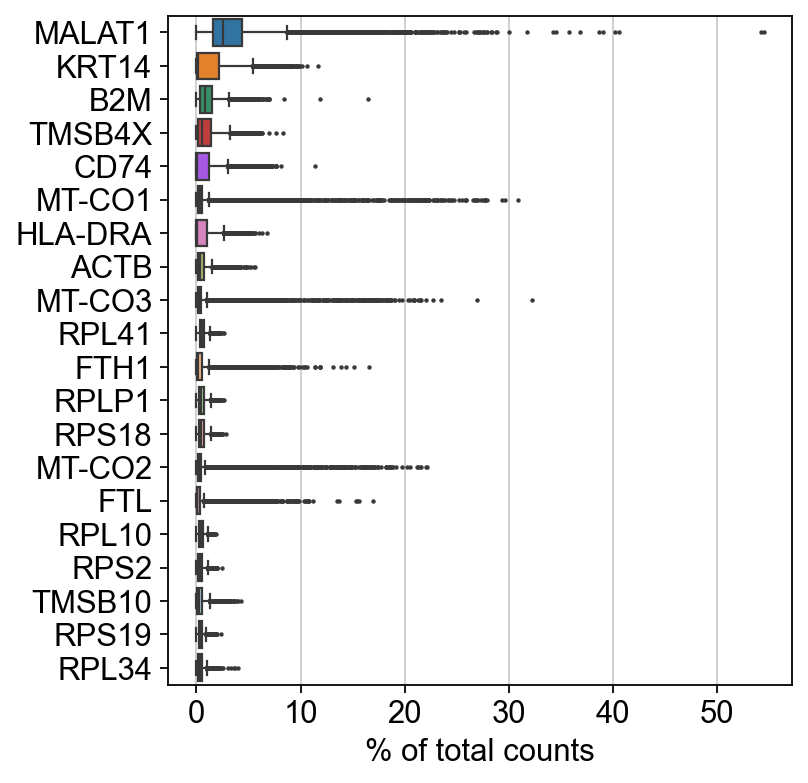

In [24]:
# Show those genes that yield the highest fraction of counts in each single cell, across all cells.
sc.pl.highest_expr_genes(adata, n_top=20)

Questions:

1)	Read in the data and perform filtering and normalisation: Explain the reason for your chosen threshold for filtering with appropriate figures and rational for normalisation?


In [25]:
# Identify the mitochondrial genes, which are generally starts with MT, 
# and the ribosomal genes that start with the RPS and RPL.

# find genes that are mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# find genes that are ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# compute QC metrics to calculates the percentage of those genes expressed in the cells.
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False, percent_top=None
)

In [26]:
# A quick check to see the number of genes by counts and the total reads
# and the percentage of mitochondrial genes and the ribosomal genes.
adata.obs[
        ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]
    ].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,31456.000000,31456.000000,31456.000000,31456.000000
mean,2510.983882,8185.354492,3.066280,15.605822
std,1410.586024,7541.133301,7.380524,8.226326
min,27.000000,436.000000,0.000000,0.000000
25%,1396.000000,2720.000000,0.911259,9.563622
50%,2331.000000,5969.500000,1.524718,15.636131
75%,3418.000000,11276.500000,2.646164,20.808786
max,9027.000000,78150.000000,98.264641,58.778625


In [27]:
# Sanity check for how many mitchondrial and ribosomal genes are tagged
adata.var.describe()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
count,36601.000000,36601.000000,36601.000000,3.660100e+04
mean,2158.015054,0.223637,93.139576,7.034740e+03
std,4182.682159,2.022680,13.296930,6.362774e+04
min,0.000000,0.000000,0.480036,0.000000e+00
25%,7.000000,0.000223,92.526068,7.000000e+00
50%,123.000000,0.004323,99.608978,1.360000e+02
75%,2351.000000,0.095530,99.977747,3.005000e+03
max,31305.000000,203.930538,100.000000,6.414839e+06


saving figure to file figures/violinQC_covariates.pdf


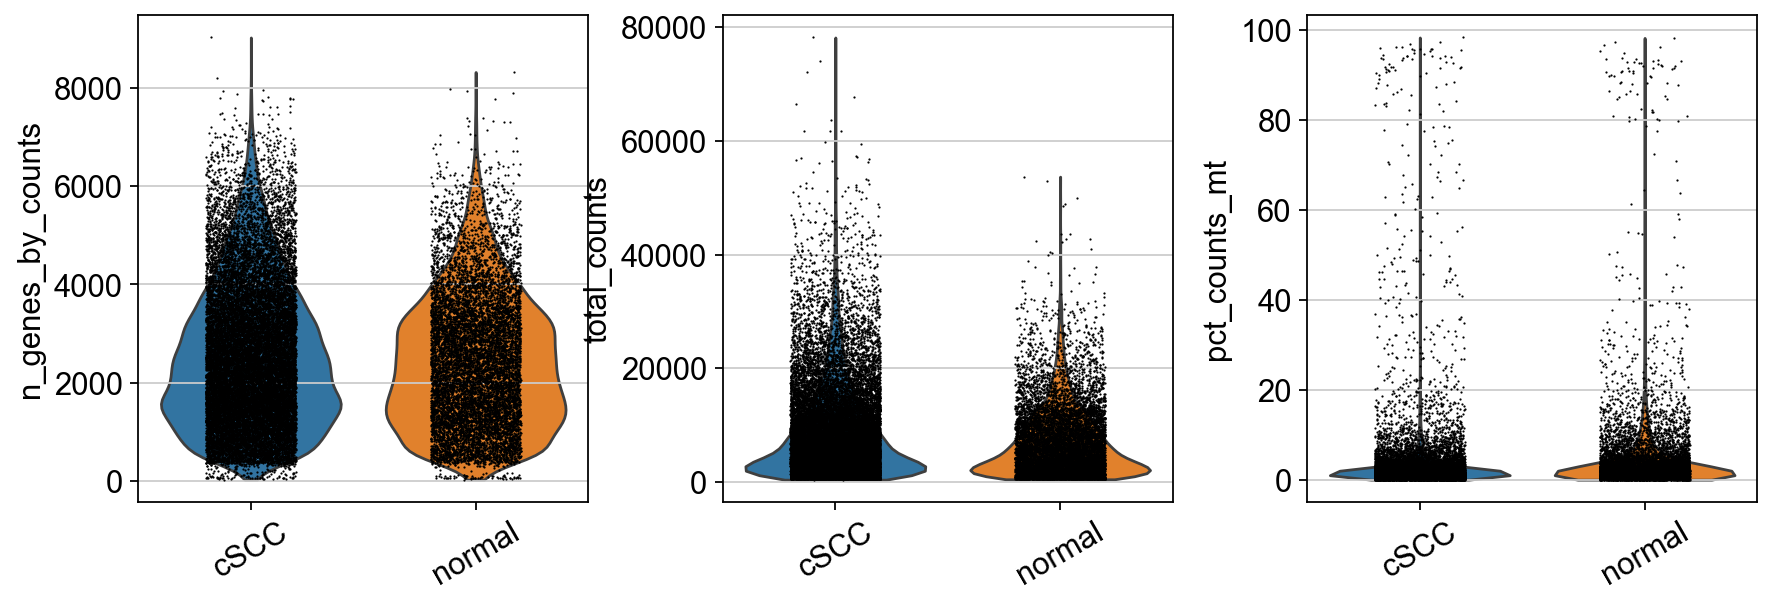

In [28]:
# Generate violin plot to visualise the normal vs cSCC quality
sc.pl.violin(
    adata,
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby='condition',
    jitter=0.2,
    multi_panel=True,
    rotation=30,
    save="QC_covariates.pdf",
    show=True,
)

* pct_counts_mt of both cSCC and normal have a very flat base near 5% representing healthy cells.
* High mitochondria percentage indicates dying or damaged cells with leaky cytoplasm.
* Every black dots above roughly 15% indicates dying cells.
* Threshold of choice: remove cells with more than 20% mitchondria genes
  
* n_genes_by_counts shows most cells are clustered between 200 - 4000 genes.
* However, there are some dots at the very bottom which indicates empty droplets or dead cells.
* There are outlier cells with >6000 genes which likely doublets
* Threshold of choice: 200 < n_genes_by_counts < 600
  
* total_counts violin in cSCC is higher than normal indicating more transcriptionally active than normal cells.
* Most cells are below 20,000

In [29]:
## Filter cells according to identified QC thresholds:
print("Total number of cells: {:d}".format(adata.n_obs))

# Remove cells expressing the mitochondrial genes more than 20%, 
adata = adata[adata.obs.pct_counts_mt < 20, :].copy()
print("Number of cells after mt filter: {:d}".format(adata.n_obs))

# Filter out cells expressing genes less than 200.
sc.pp.filter_cells(adata, min_genes=200)
print("Number of cells after gene filter: {:d}".format(adata.n_obs))

# Upper threshold for removing doublets
sc.pp.filter_cells(adata, max_genes=6000)
print("Number of cells after upper gene filter: {:d}".format(adata.n_obs))

Total number of cells: 31456
Number of cells after mt filter: 30935
Number of cells after gene filter: 30935
Number of cells after upper gene filter: 30470


In [30]:
# Remove mitchondria and ribosomal genes

print(adata.shape[1])
adata = adata[:, ~adata.var["mt"].values]
print("After mt genes removal: ", adata.shape[1])
adata = adata[:, ~adata.var["ribo"].values]
print("After ribo genes removal: ", adata.shape[1])

36601
After mt genes removal:  36588
After ribo genes removal:  36485


Normalise + log transform + HVG¶

In [31]:
# Preserve raw data
adata.layers["raw"] = adata.X.copy()  

# Normalise all counts to 10,000 reads per cell by assuming that all cells have 10,000 molecules and all mRNA molecules are normalised to that final number. 
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)

# Add this as another layer to data object
adata.layers["normalised"] = adata.X.copy()

# Logarithmize the data
# Some mRNA molecules might have 0 count, so need to add one to all the counts.
sc.pp.log1p(adata)

# Add this as another layer to data object
adata.layers["log1p"] = adata.X.copy()

# Keep original raw counts for later differential testing and visualisation of gene expression
adata.raw = adata  

/var/folders/v7/_vrzk32n4n31xckt07fgcpbw0000gn/T/ipykernel_75821/3693833883.py:2: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers["raw"] = adata.X.copy()


Next is to extract highly variable genes (HVGs) which is basically to get the main information from our cells. Some genes are highly expressed while some were donw-regulated. This variations help to distinguish one cell type from another. By selecting HVGs keep only the most informative genes for clustering and dimensionality reduction. This will reduce noise, speed up computation, improve cluster seperation and make biological differences clearer. I'm going to set n_top_genes to 3000 because skin is a highly heterogeneous tissue containing many cell types. It is important to capture subtle transcriptomic differences between malignant and normal skin cells.

In [32]:
import sys
!{sys.executable} -m pip install scikit-misc

In [33]:
sc.pp.highly_variable_genes(
    adata,
    subset=True,  # subset for integration (but full lognorm data in .raw)
    layer="raw",
    flavor="seurat_v3",
    n_top_genes=3000,
    span=0.3,
    min_disp=0.5,
    min_mean=0.0125,
    max_mean=3,
)

In [34]:
# Confirm adata.X has been correctly subsetted to 3000 HVGs
print(adata.X.shape)

# Check adata.raw still have all genes for later differential expression testing.
print(adata.raw.X.shape)

(30470, 3000)
(30470, 36485)


The two unwanted technical signals can still influence the data, they are total counts per cell and the percentage of mitochondrial genes expressed. Sequencing depth artifact could lead to variation of total amount of RNA across different cells and if there are more RNA in some cells could mistakenly interpreted as more acitve than cells with less RNA. Also. dying or stressed cells have high mitochondrial expression therefore they will cluster together based on stress level rather than cell type identity. By performing regress out effects of total counts per cell and the percentage of mitochondrial genes expressed, it will reduce technical bias and revealing more biological differences between cancer and match normal.

In [35]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

# Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

print("After scaling - Max:", np.max(adata.X))
print("After scaling - Mean:", np.mean(adata.X))

After scaling - Max: 10.0
After scaling - Mean: -0.006820366


Dimensionality reduction with PCA (Principal Component Analysis)

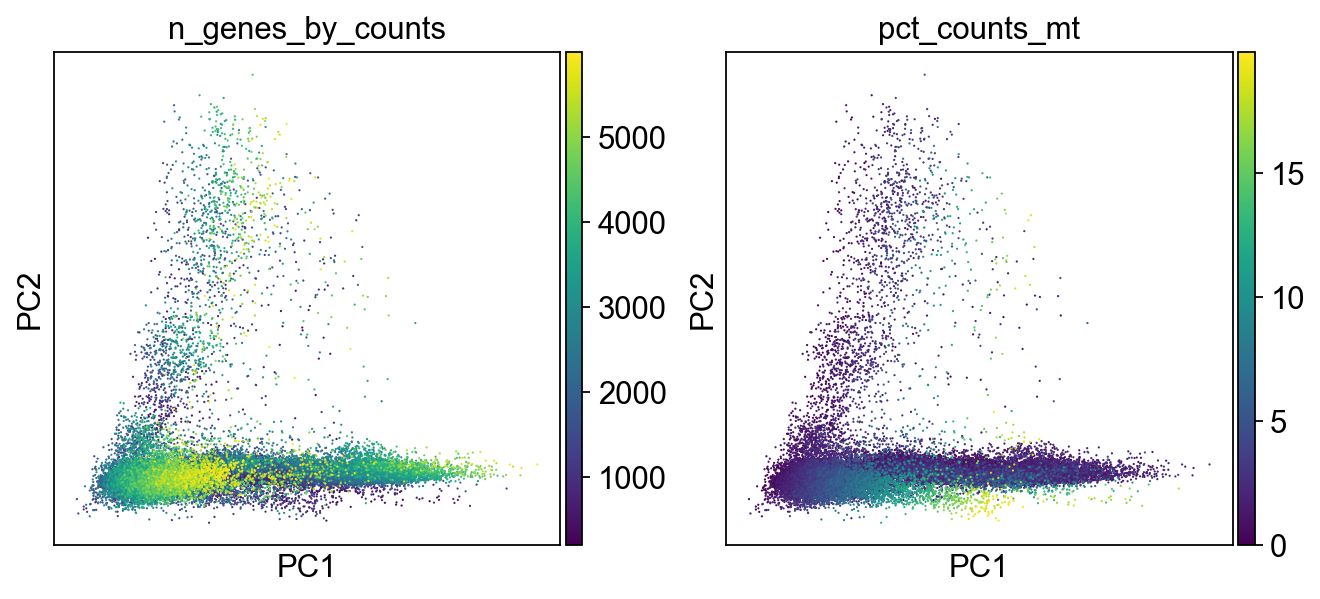

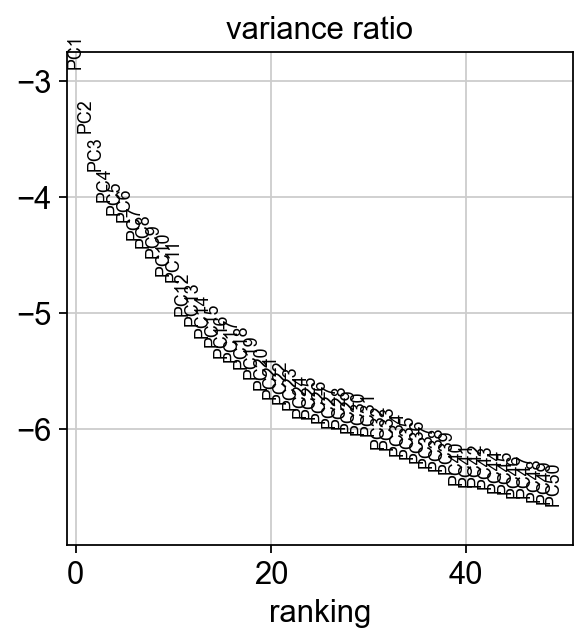

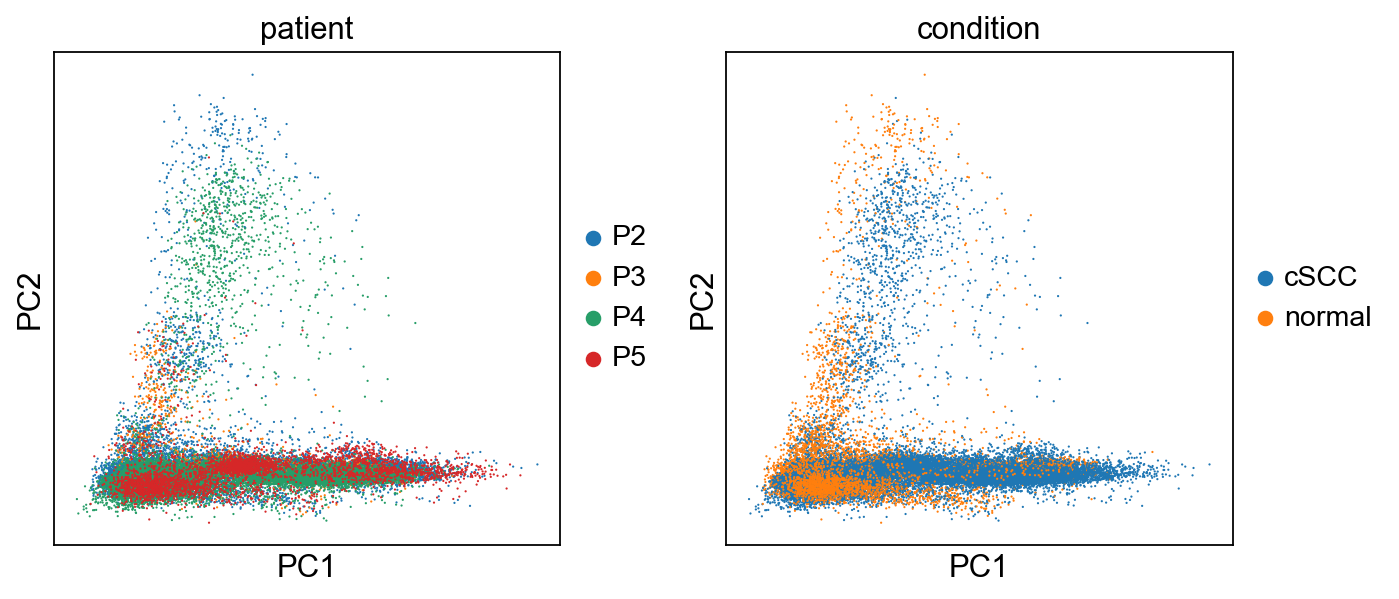

In [36]:
# Calculate PCA
sc.tl.pca(adata, svd_solver='arpack')

# Scatter plot for PCA coloured by QC metrics
sc.pl.pca(adata, color=['n_genes_by_counts', 'pct_counts_mt'], color_map='viridis')

# Estimate number of PCs to use
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

# Shows batch effect by patient and condition
sc.pl.pca(adata, color=['patient', 'condition'])

Explanation for n_gene_by_counts: Yellow dots indicates high gene counts and are observed in this PCA plot suggesting majority of cells have high gene counts.

Explanation for pct_counts_mt: % of mitchondrial is mostly low as shown in purple dots suggesting MT filtering has worked.

Explanation for variance ratio: This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells. There is no sharp elbow, although the curve drops more steeply frpm PC1 to PC10. The curve gradually declining past PC20, then more flatten at PC40. I would use PC30 as meaningful information may still present before PC30. 

Explanation for patient plot: Patient 2 (blue) and 5 (red) are more separated, whereas cells belong to other patients cluster more together. This suggests a batch effect exists.

Explanation for condition plot: normal and cSCC cells are partially separated along PC1 indicating biological differences are present.

Computing and embedding the neighborhood graph of cells using the PCA representation of the data matrix. 

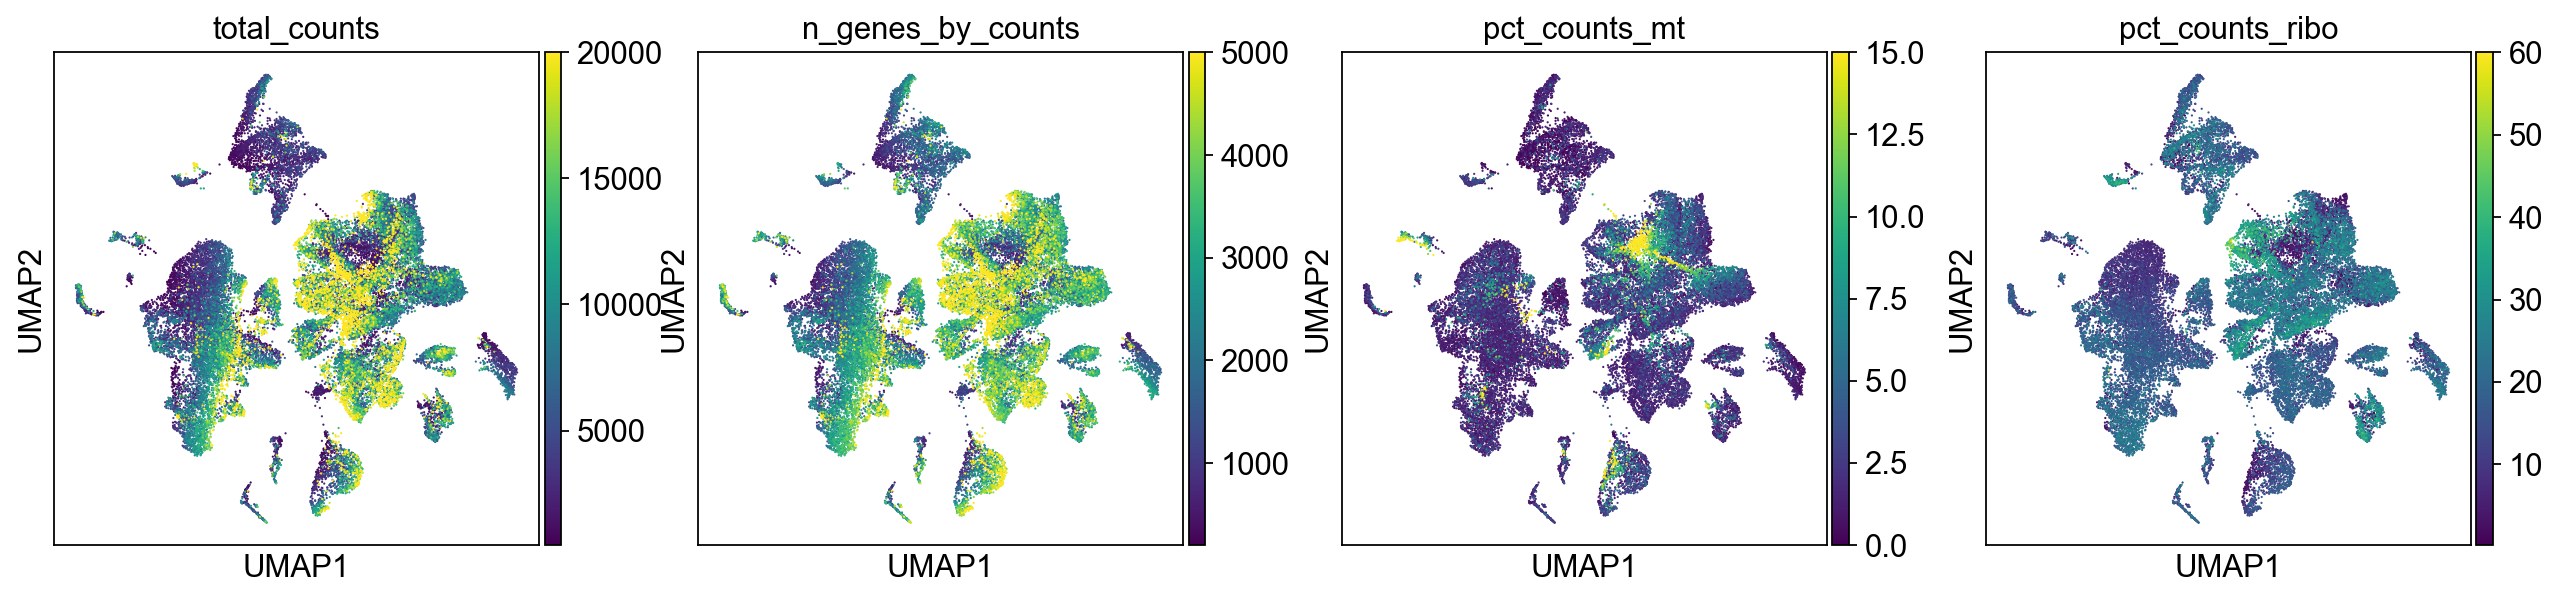

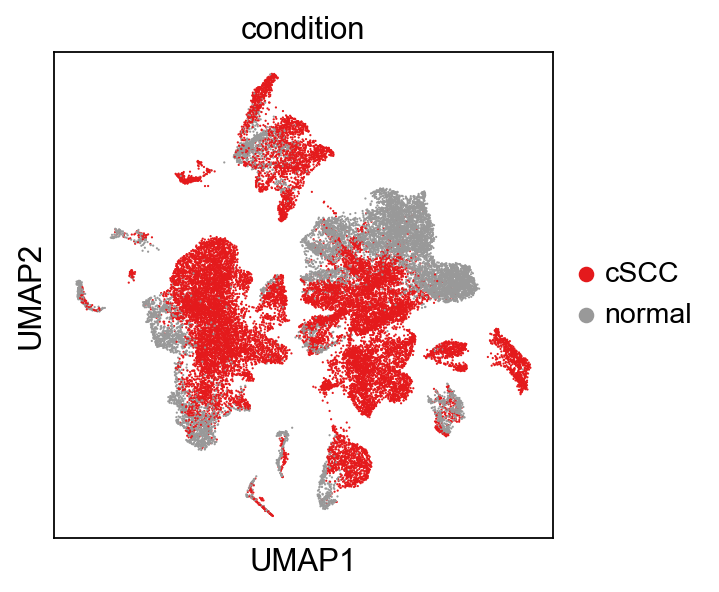

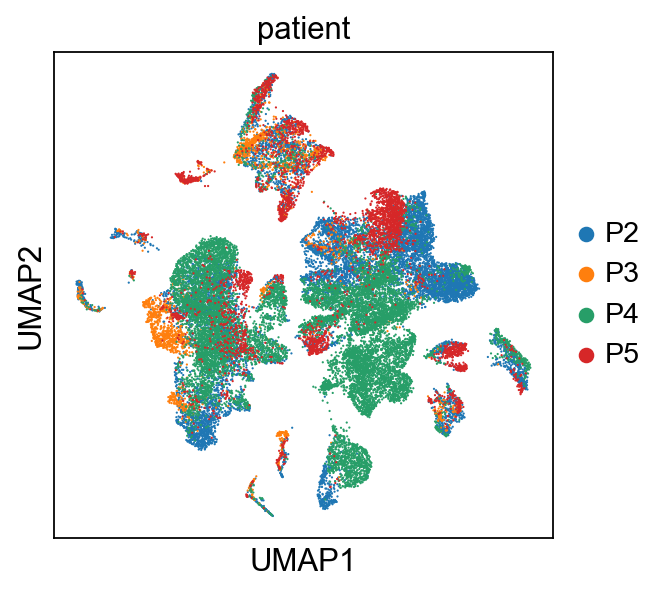

In [37]:
# Set n_pcs based on elbow plot
n_pcs = 30

# Compute neighbourhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs, random_state=7)

# Embed neighbourhood graph
sc.tl.umap(adata)

# Plot 1: QC metrics - check for technically driven clusters
sc.pl.umap(
    adata,
    color=['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    color_map='viridis',
    vmax=[20000, 5000, 15, 60],
    ncols=4
)

# Plot 2: Condition - cSCC vs normal
sc.pl.umap(adata, color=['condition'], palette='Set1')

# Plot 3: Patient - check for batch effect
sc.pl.umap(adata, color=['patient'])